In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

In [2]:
q1 = 1
m1 = 1
q2 = -1
m2 = 1
A =[2, 1]
B = [3, 5]
k = 20

In [3]:
def x1(t):
    return A[0] + t**2*np.cos(np.sqrt(t))/10 - t

def y1(t):
    return A[1] + t*np.sin(t) + 1/(t+1)

def r1(t):
    return np.array([x1(t), y1(t)])

In [4]:
T = 10
dt = 0.1
timespan = np.linspace(0, T, int(T/dt))


In [5]:
from scipy import integrate



def F(t, U2):
    r2, v2 = np.array(U2[:2]), np.array(U2[2:])
    r = r2 - r1(t)
    if np.linalg.norm(r) < 10e-3:
        return[*v2, 0, 0]
    return [*v2, *(k * q1 * q2 / np.linalg.norm(r)**3 * r / m2)]


def track_progress(t, y):
    print(f"Time: {t}, State: {y}") 

sol = integrate.solve_ivp(F, (0, T), [*np.array(B), 0,0], t_eval=timespan)

In [6]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 3.000e+00  2.997e+00 ... -3.302e+00 -3.347e+00]
            [ 5.000e+00  4.991e+00 ...  2.060e+01  2.076e+01]
            [ 0.000e+00 -6.369e-02 ... -4.470e-01 -4.482e-01]
            [ 0.000e+00 -1.846e-01 ...  1.652e+00  1.650e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 152
     njev: 0
      nlu: 0

In [7]:
def x2(t):
    return sol.y[0][int(t/dt)]

def y2(t):
    return sol.y[1][int(t/dt)]

def r2(t):
    return np.array(x2(t), y2(t))

# Visualizing 1-st charge

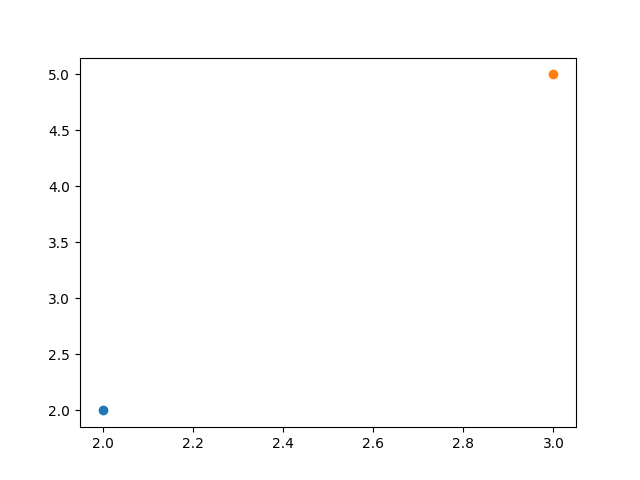

In [10]:

fig, ax1 = plt.subplots()
traj1, = ax1.plot(x1(0), y1(0), '-b')
pos1, = ax1.plot(x1(0), y1(0), marker='o')# ax1.scatter(x1(0), y1(0), '+r')
traj2, = ax1.plot(x2(0), y2(0), '-r')
pos2, = ax1.plot(x2(0), y2(0), marker='o')# ax2.scatter(x2(0), y2(0), '+r')


def animate(t_max):
    times = timespan[:int(t_max/dt)]
    traj1.set_data([x1(t) for t in times], [y1(t) for t in times])
    pos1.set_data([x1(t_max)], [y1(t_max)])
    
    traj2.set_data([x2(t) for t in times], [y2(t) for t in times])
    pos2.set_data([x2(t_max)], [y2(t_max)])
anim_running = True

def onClick(event):
    global anim_running
    if anim_running:
        ani.event_source.stop()
        anim_running = False
    else:
        ani.event_source.start()
        anim_running = True


def init():
    
    
    ax1.set_ylim(-5, 30)
    ax1.set_xlim(-20, 5)
    ax1.axhline(0, color='black', lw=1)
    ax1.axvline(0, color='black', lw=1)

    plt.rcParams.update({'font.size': 10})

    return traj1, traj2


ani = FuncAnimation(fig, animate, timespan, init_func=init, interval=50, blit=True,)
fig.canvas.mpl_connect('button_press_event', onClick)

plt.show()

# Modelling collisions